<a href="https://www.kaggle.com/code/sonawanelalitsunil/electric-vehicle-population-2025?scriptVersionId=258148591" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/electric-vehicle-population-data-2025/Electric_Vehicle_Population_Data.csv


## 🚗⚡ Electric Vehicle Population 2025

## Description:
The Electric Vehicle Population 2025 dataset provides a comprehensive overview of registered electric vehicles (EVs) up to the year 2025. It includes detailed information on vehicle characteristics such as make, model, model year, vehicle type, range, electric utility, clean alternative fuel eligibility, and location data (state, city, postal code). This dataset is valuable for analyzing EV adoption trends, understanding regional distribution, studying the impact of EV policies, and forecasting future growth in sustainable transportation. Researchers, policymakers, and automotive companies can use it to gain insights into consumer preferences, charging infrastructure needs, and the evolution of the electric mobility ecosystem.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/electric-vehicle-population-data-2025/Electric_Vehicle_Population_Data.csv")

In [3]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJSA1E65N,Yakima,Granger,WA,98932.0,2022,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,187279214,POINT (-120.1871 46.33949),PACIFICORP,5.307700e+10
1,KNDC3DLC5N,Yakima,Yakima,WA,98902.0,2022,KIA,EV6,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,210098241,POINT (-120.52041 46.59751),PACIFICORP,5.307700e+10
2,5YJYGDEEXL,Snohomish,Everett,WA,98208.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,44.0,121781950,POINT (-122.18637 47.89251),PUGET SOUND ENERGY INC,5.306104e+10
3,3C3CFFGE1G,Yakima,Yakima,WA,98908.0,2016,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,14.0,180778377,POINT (-120.60199 46.59817),PACIFICORP,5.307700e+10
4,KNDCC3LD5K,Kitsap,Bremerton,WA,98312.0,2019,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,0.0,26.0,2581225,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303508e+10


In [4]:
df.tail()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
250654,7SAYGDEE7S,Franklin,Pasco,WA,99301.0,2025,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,9.0,274986323,POINT (-119.09467 46.23542),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF F...,5.302102e+10
250655,2C4RC1L77J,Pierce,Tacoma,WA,98407.0,2018,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,33.0,0.0,27.0,128901748,POINT (-122.51134 47.29238),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305306e+10
250656,7SAYGDEF6P,Pierce,Bonney Lake,WA,98391.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,31.0,258537660,POINT (-122.17144 47.19175),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
250657,WBY8P6C54K,King,Seattle,WA,98117.0,2019,BMW,I3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,153.0,0.0,36.0,477080334,POINT (-122.38418 47.70044),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
250658,JTMAB3FV8P,Klickitat,Goldendale,WA,98620.0,2023,TOYOTA,RAV4 PRIME (PHEV),Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,14.0,255440223,POINT (-120.82545 45.823),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF K...,5.303995e+10


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250659 entries, 0 to 250658
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         250659 non-null  object 
 1   County                                             250653 non-null  object 
 2   City                                               250653 non-null  object 
 3   State                                              250659 non-null  object 
 4   Postal Code                                        250653 non-null  float64
 5   Model Year                                         250659 non-null  int64  
 6   Make                                               250659 non-null  object 
 7   Model                                              250659 non-null  object 
 8   Electric Vehicle Type                              250659 non-null  object

In [6]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,250653.000000,250659.000000,250638.000000,250638.000000,250076.000000,2.506590e+05,2.506530e+05
mean,98176.796089,2021.628252,44.073002,727.403107,28.994994,2.392132e+08,5.297386e+10
std,2555.064640,3.021254,82.412875,6917.315299,14.862288,6.671019e+07,1.618543e+09
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,0.000000,18.000000,2.111858e+08,5.303301e+10
50%,98126.000000,2023.000000,0.000000,0.000000,33.000000,2.575374e+08,5.303303e+10
75%,98382.000000,2024.000000,37.000000,0.000000,42.000000,2.728702e+08,5.305394e+10
max,99577.000000,2026.000000,337.000000,845000.000000,49.000000,4.792548e+08,6.601095e+10


In [7]:
df.dtypes

VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Base MSRP                                            float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census Tract       

In [8]:
df.shape

(250659, 17)

In [9]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 6
City                                                   6
State                                                  0
Postal Code                                            6
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        21
Base MSRP                                             21
Legislative District                                 583
DOL Vehicle ID                                         0
Vehicle Location                                      14
Electric Utility                                       6
2020 Census Tract                                      6
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

## data visualizations

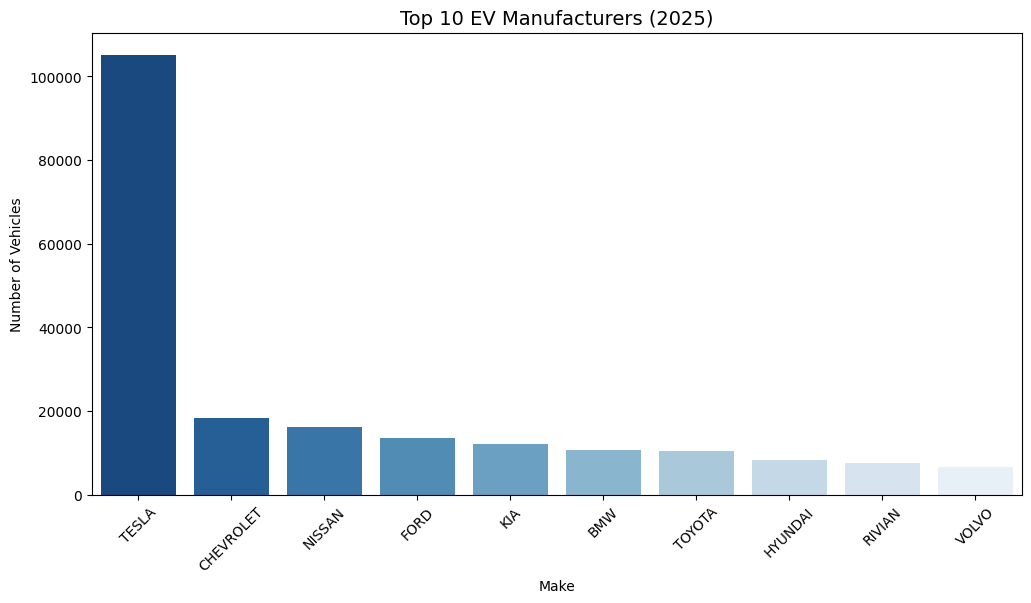

In [12]:
plt.figure(figsize=(12,6))
top_makes = df['Make'].value_counts().head(10)  # Top 10 EV manufacturers
sns.barplot(x=top_makes.index, y=top_makes.values, palette="Blues_r")
plt.title("Top 10 EV Manufacturers (2025)", fontsize=14)
plt.xlabel("Make")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

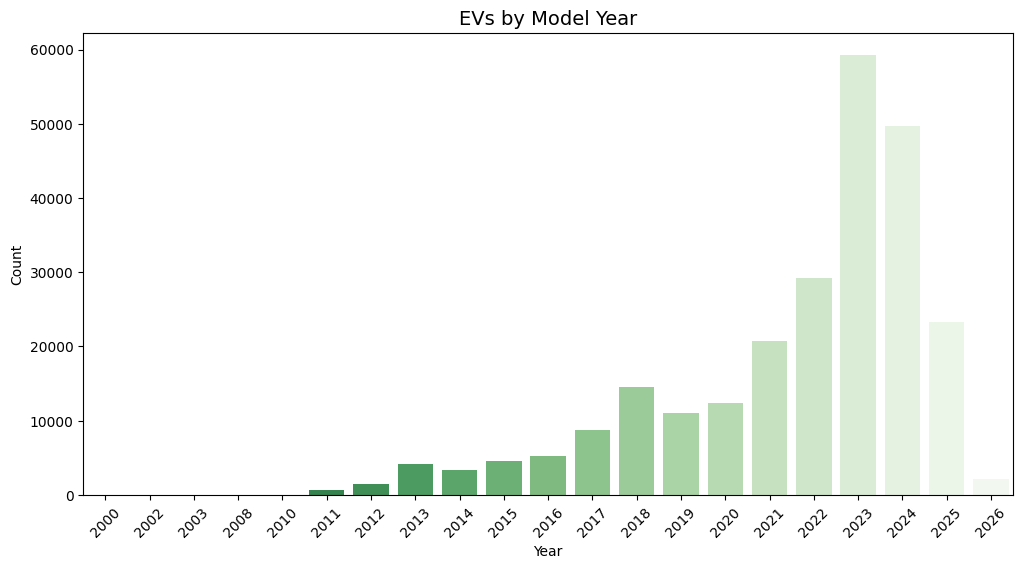

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Model Year", palette="Greens_r", order=sorted(df["Model Year"].unique()))
plt.title("EVs by Model Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

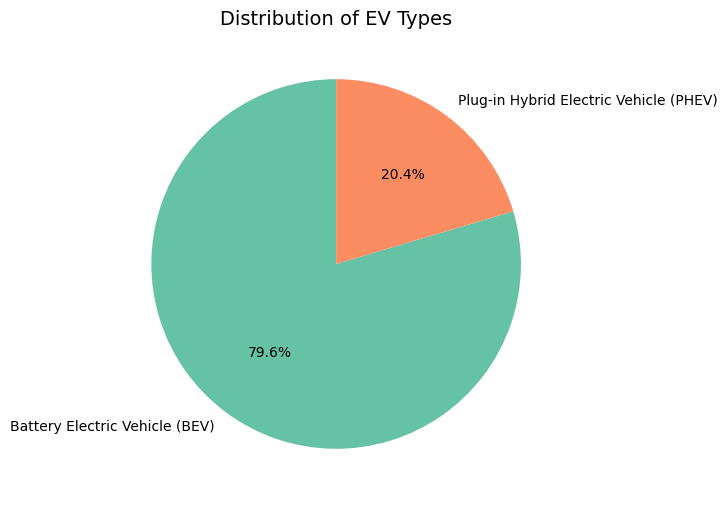

In [14]:
plt.figure(figsize=(6,6))
df['Electric Vehicle Type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, 
                                                    colors=sns.color_palette("Set2"))
plt.title("Distribution of EV Types", fontsize=14)
plt.ylabel("")
plt.show()

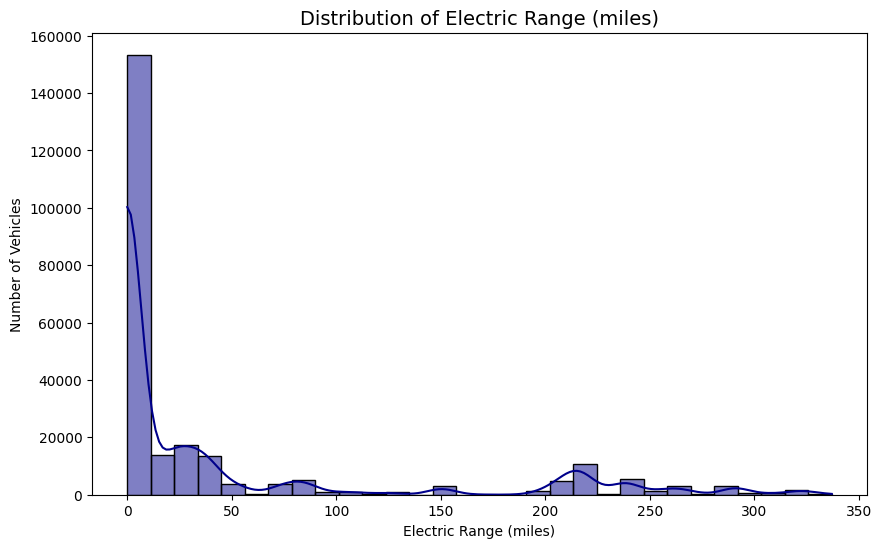

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['Electric Range'], bins=30, kde=True, color="darkblue")
plt.title("Distribution of Electric Range (miles)", fontsize=14)
plt.xlabel("Electric Range (miles)")
plt.ylabel("Number of Vehicles")
plt.show()

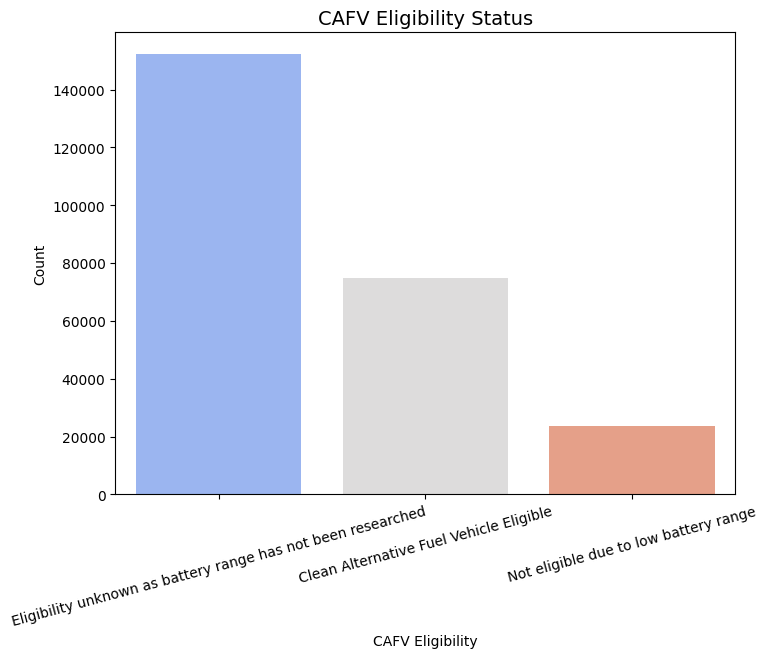

In [16]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Clean Alternative Fuel Vehicle (CAFV) Eligibility", palette="coolwarm")
plt.title("CAFV Eligibility Status", fontsize=14)
plt.xlabel("CAFV Eligibility")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

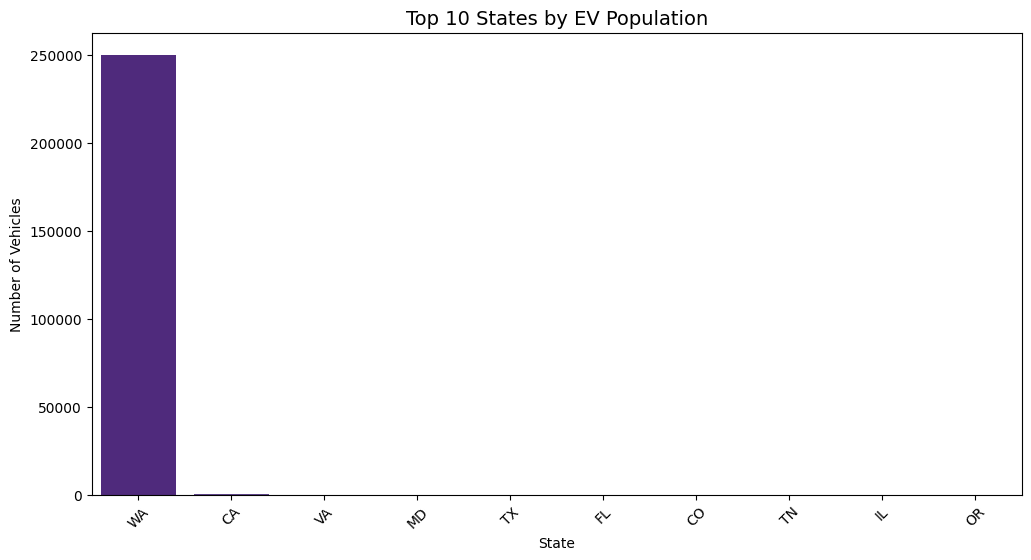

In [17]:
plt.figure(figsize=(12,6))
top_states = df['State'].value_counts().head(10)
sns.barplot(x=top_states.index, y=top_states.values, palette="Purples_r")
plt.title("Top 10 States by EV Population", fontsize=14)
plt.xlabel("State")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

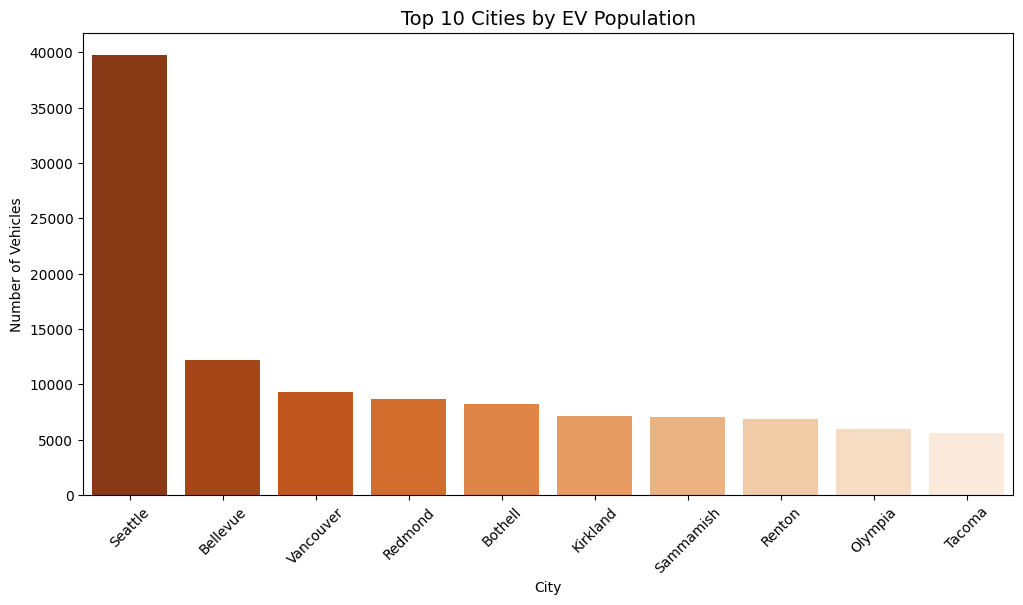

In [18]:
plt.figure(figsize=(12,6))
top_cities = df['City'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values, palette="Oranges_r")
plt.title("Top 10 Cities by EV Population", fontsize=14)
plt.xlabel("City")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.show()

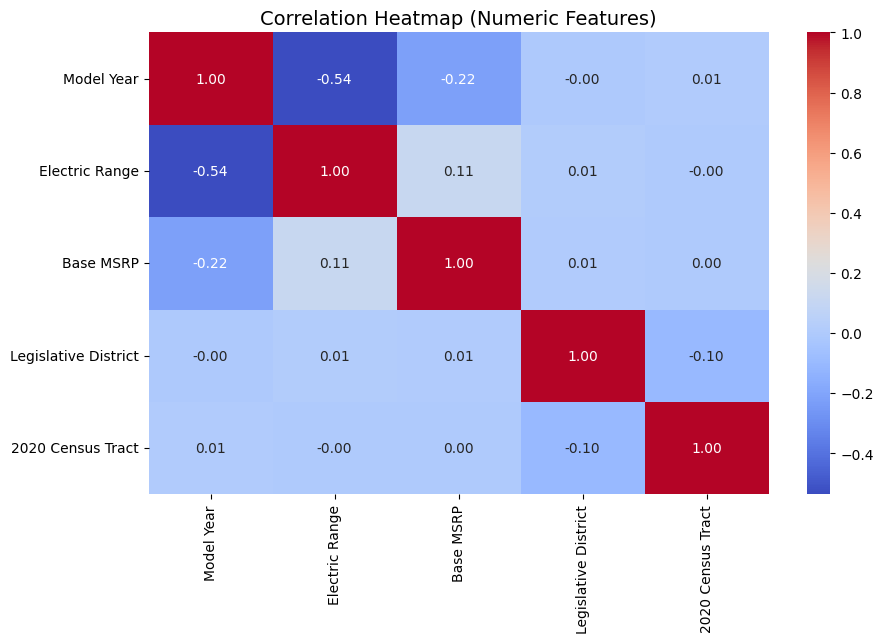

In [19]:
plt.figure(figsize=(10,6))
numeric_cols = ['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District', '2020 Census Tract']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)", fontsize=14)
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

In [21]:
target = "Electric Vehicle Type"
X = df.drop(columns=[target])
y = df[target]

# Label Encoding
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

y_le = LabelEncoder()
y = y_le.fit_transform(y)

In [22]:
imputer = SimpleImputer(strategy="most_frequent")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, solver='lbfgs', n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, max_depth=5),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Naive Bayes": GaussianNB()
}

In [24]:
imputer = SimpleImputer(strategy="most_frequent")  # you can also try "mean" for numeric
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [25]:
# Encode target as well
y_le = LabelEncoder()
y = y_le.fit_transform(y)

# --- Step 3: Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, solver='lbfgs'),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}


In [27]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    results.append((name, acc))

results_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy (%)"])
print(results_df)

             Algorithm  Accuracy (%)
0  Logistic Regression     79.605841
1        Decision Tree     99.994016
2        Random Forest     99.990026
3    Gradient Boosting     99.986037
4                  KNN     76.910955
5                  SVM     79.605841
6          Naive Bayes     79.516078
7              XGBoost     99.992021


## Thank you..pls upvote!!!